In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

df = pd.read_csv('Resources/Data/proton_loans.csv')

In [2]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001011,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            791 non-null    str    
 1   Married            791 non-null    str    
 2   Dependents         791 non-null    str    
 3   Education          791 non-null    str    
 4   Self_Employed      791 non-null    str    
 5   ApplicantIncome    791 non-null    int64  
 6   CoapplicantIncome  791 non-null    float64
 7   LoanAmount         791 non-null    float64
 8   Loan_Amount_Term   791 non-null    float64
 9   Credit_History     791 non-null    float64
 10  Property_Area      791 non-null    str    
 11  Loan_Status        791 non-null    int64  
dtypes: float64(4), int64(2), str(6)
memory usage: 74.3 KB


In [4]:
df.describe(include='all')

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,791,791,791,791,791,791.000000,791.000000,791.000000,791.000000,791.000000,791,791.000000
unique,791,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,NaN
top,LP001003,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,NaN
freq,1,510,454,624,688,NaN,NaN,NaN,NaN,NaN,287,NaN
mean,NaN,NaN,NaN,NaN,NaN,5190.077118,1555.552364,142.567636,342.245259,0.847029,NaN,0.428571
std,NaN,NaN,NaN,NaN,NaN,5677.816273,2506.049736,75.895399,65.011980,0.360187,NaN,0.495185
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,9.000000,6.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,2885.500000,0.000000,100.500000,360.000000,1.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,3846.000000,1032.000000,128.000000,360.000000,1.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,5575.500000,2333.000000,163.500000,360.000000,1.000000,NaN,1.000000


In [5]:
df.columns

Index(['Loan_ID', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [6]:
df["Loan_Status"].value_counts()

Loan_Status
0    452
1    339
Name: count, dtype: int64

In [ ]:


X = df[['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'] + ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

categorical = ['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
           'Loan_Amount_Term', 'Credit_History']


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num", StandardScaler(), numeric),
    ]
).set_output(transform="pandas")





In [10]:
X_pre = preprocess.fit_transform(X)
X_pre.describe()

,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num__ApplicantIncome,num__CoapplicantIncome,num__LoanAmount,num__Loan_Amount_Term,num__Credit_History
count,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02
mean,0.644753,0.158028,0.173198,0.094817,0.211125,0.130215,0.362832,0.340076,-7.635415e-17,-9.544269e-17,-9.656554e-17,-1.841482e-16,4.828277e-17
std,0.478891,0.364998,0.378658,0.293147,0.408365,0.336753,0.481121,0.474034,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.146758e-01,-6.211116e-01,-1.761005e+00,-5.175323e+00,-2.353123e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.061483e-01,-6.211116e-01,-5.546351e-01,2.732723e-01,4.249671e-01
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.368741e-01,-2.090476e-01,-1.920650e-01,2.732723e-01,4.249671e-01
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,6.792519e-02,3.104246e-01,2.759799e-01,2.732723e-01,4.249671e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.336040e+01,1.288956e+01,7.349392e+00,2.120254e+00,4.249671e-01


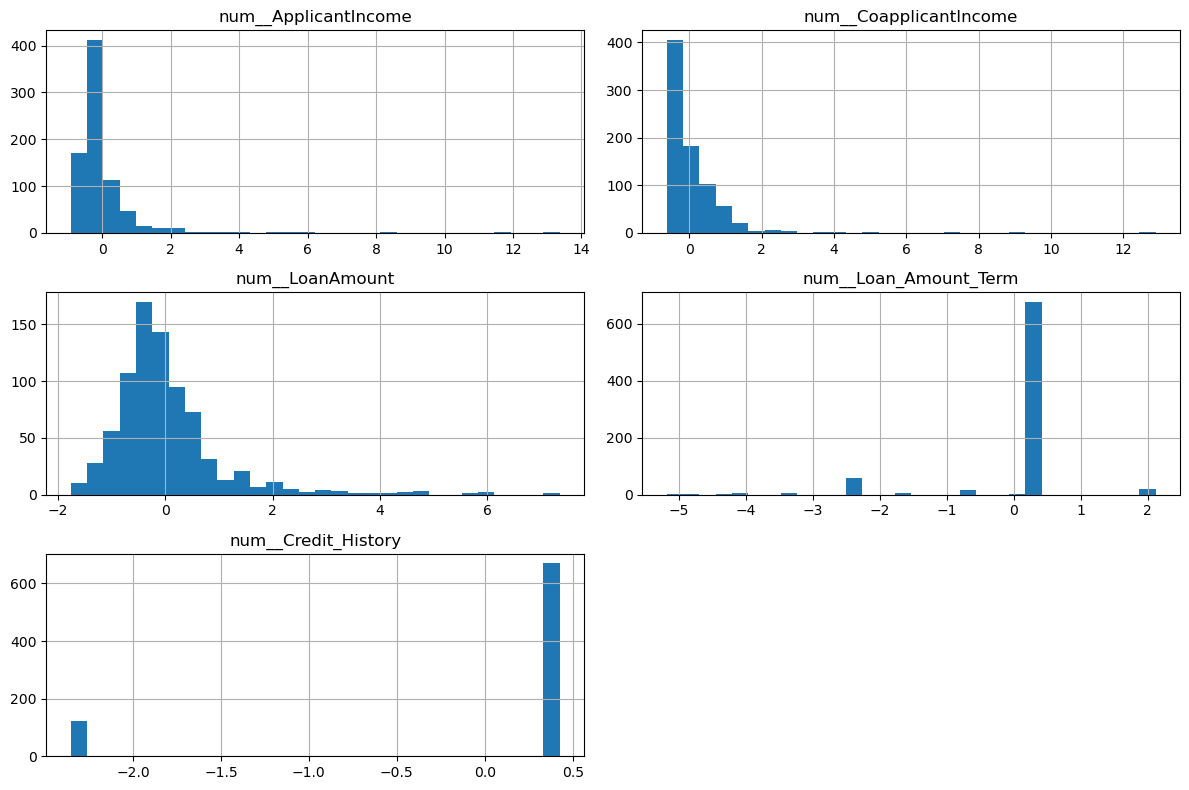

In [11]:

num_cols_scaled = [c for c in X_pre.columns if c.startswith("num__")]

X_pre[num_cols_scaled].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [17]:




log_transformer = FunctionTransformer(np.log1p)

X = df[['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'] + ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

categorical = ['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric_log = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]
numeric = ['Loan_Amount_Term', 'Credit_History']


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num_log", Pipeline([
            ("log", log_transformer),
            ("scale", StandardScaler())
        ]), numeric_log),

        ("num", StandardScaler(), numeric),
    ]
).set_output(transform="pandas")



In [19]:
X_pre = preprocess.fit_transform(X)
X_pre.describe()



,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num_log__ApplicantIncome,num_log__CoapplicantIncome,num_log__LoanAmount,num__Loan_Amount_Term,num__Credit_History
count,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02
mean,0.644753,0.158028,0.173198,0.094817,0.211125,0.130215,0.362832,0.340076,1.769620e-15,-3.031709e-17,-3.593136e-16,-1.841482e-16,4.828277e-17
std,0.478891,0.364998,0.378658,0.293147,0.408365,0.336753,0.481121,0.474034,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.135376e+01,-1.103514e+00,-5.383387e+00,-5.175323e+00,-2.353123e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.677639e-01,-1.103514e+00,-4.958621e-01,2.732723e-01,4.249671e-01
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.530948e-02,6.945004e-01,9.803718e-03,2.732723e-01,4.249671e-01
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.319333e-01,9.056738e-01,5.224878e-01,2.732723e-01,4.249671e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.087879e+00,1.598431e+00,3.579697e+00,2.120254e+00,4.249671e-01


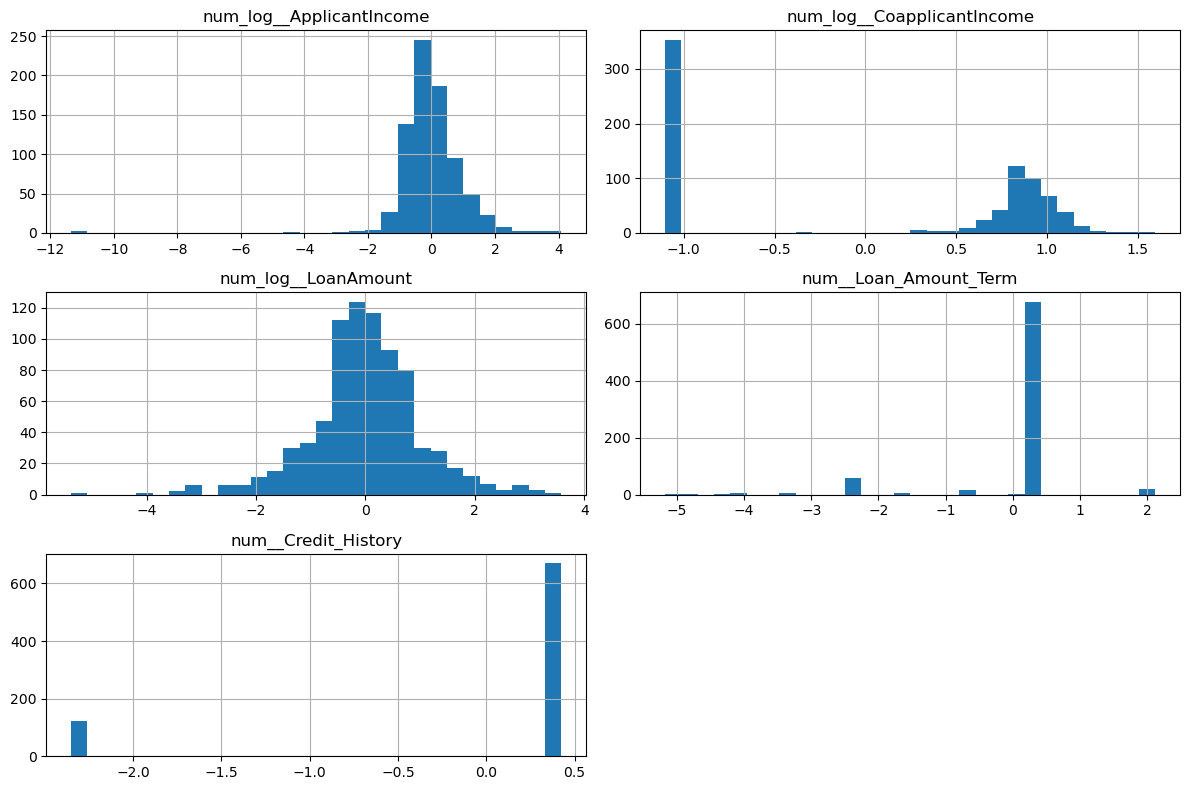

In [20]:
num_cols_scaled = [c for c in X_pre.columns if c.startswith("num_")]

X_pre[num_cols_scaled].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

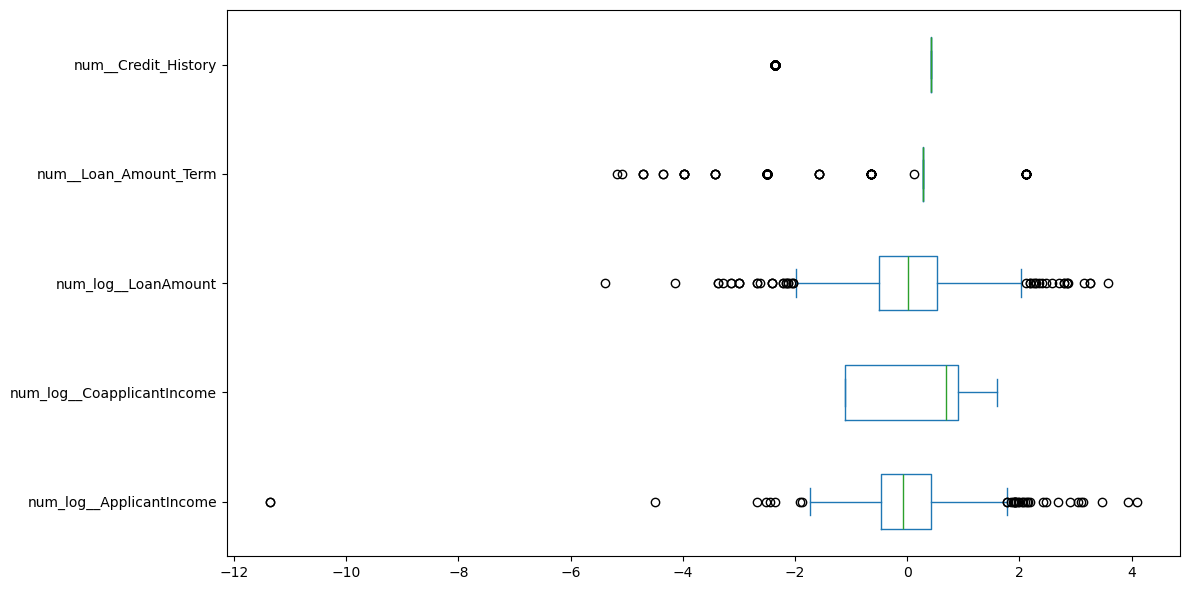

In [21]:

X_pre[num_cols_scaled].plot.box(figsize=(12, 6), vert=False)
plt.tight_layout()
plt.show()

In [22]:
pipe = Pipeline(
    [
        ("prep", preprocess),
        ("logreg", LogisticRegression(max_iter=100))
    ]
)

pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [23]:
logreg = pipe.named_steps["logreg"]

In [24]:
X.head()

,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Yes,1,Graduate,No,Rural,4583,1508.0,128.0,360.0,1.0
1,Yes,0,Graduate,Yes,Urban,3000,0.0,66.0,360.0,1.0
2,Yes,0,Not Graduate,No,Urban,2583,2358.0,120.0,360.0,1.0
3,No,0,Graduate,No,Urban,6000,0.0,141.0,360.0,1.0
4,Yes,2,Graduate,Yes,Urban,5417,4196.0,267.0,360.0,1.0


In [29]:


feature_names = X_pre.columns

coef_table = pd.Series(
    pipe.named_steps["logreg"].coef_[0],
    index=feature_names
)
coef_table


cat__Married_Yes                0.199104
cat__Dependents_1              -0.111349
cat__Dependents_2               0.203185
cat__Dependents_3+              0.017501
cat__Education_Not Graduate    -0.273000
cat__Self_Employed_Yes          0.005442
cat__Property_Area_Semiurban    0.672314
cat__Property_Area_Urban       -0.067632
num_log__ApplicantIncome        0.222386
num_log__CoapplicantIncome      0.132475
num_log__LoanAmount            -0.142362
num__Loan_Amount_Term          -0.020330
num__Credit_History             0.977558
dtype: float64

In [30]:

odds_ratios = np.exp(coef_table)
odds_ratios


cat__Married_Yes                1.220309
cat__Dependents_1               0.894626
cat__Dependents_2               1.225299
cat__Dependents_3+              1.017655
cat__Education_Not Graduate     0.761093
cat__Self_Employed_Yes          1.005457
cat__Property_Area_Semiurban    1.958765
cat__Property_Area_Urban        0.934604
num_log__ApplicantIncome        1.249054
num_log__CoapplicantIncome      1.141650
num_log__LoanAmount             0.867307
num__Loan_Amount_Term           0.979875
num__Credit_History             2.657958
dtype: float64

In [31]:

prep = pipe.named_steps["prep"]
X_preprocessed = prep.transform(X)
X_pre_df = pd.DataFrame(
    X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed,
    columns=feature_names,
    index=X.index
)
X_pre_df.head()


,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num_log__ApplicantIncome,num_log__CoapplicantIncome,num_log__LoanAmount,num__Loan_Amount_Term,num__Credit_History
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.164164,0.792683,0.009804,0.273272,0.424967
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.414615,-1.103514,-1.371843,0.273272,0.424967
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.619015,0.908434,-0.125218,0.273272,0.424967
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.532169,-1.103514,0.212299,0.273272,0.424967
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.392539,1.057693,1.551850,0.273272,0.424967


In [32]:
pd.crosstab(df["Credit_History"], df["Loan_Status"])

Loan_Status,0,1
Credit_History,,
0.0,114,7
1.0,338,332


In [ ]:
df[numeric].corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.112560,0.523961,-0.006386,0.009361
CoapplicantIncome,-0.112560,1.000000,0.183219,-0.006419,-0.043819
LoanAmount,0.523961,0.183219,1.000000,0.058222,-0.024464
Loan_Amount_Term,-0.006386,-0.006419,0.058222,1.000000,0.010037
Credit_History,0.009361,-0.043819,-0.024464,0.010037,1.000000
